# 02 · 도구 투어 — Pandas · NumPy · 시각화 30 분

이 노트북은 1 모듈부터 마주칠 도구의 *핵심 30%* 를 빠르게 훑습니다. 여기서 모든 것을 외우려 하지 말고, *어떤 모양의 코드가 가능한지* 만 눈에 익혀 두세요. 막힐 때 다시 돌아오면 됩니다.

셀을 위에서부터 순서대로 실행하세요.


## 0. 준비


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(seed=42)
sns.set_theme(context="notebook", style="whitegrid")


## 1. NumPy — 벡터화 사고

for-loop 으로 일일이 더하지 않고, 배열 단위로 한 번에 계산하는 사고가 핵심입니다.


In [2]:
# 정규분포에서 1000 개의 표본을 한 번에 뽑는다
x = rng.normal(loc=170, scale=8, size=1000)
print(f"표본 수: {len(x)}")
print(f"평균: {x.mean():.2f}, 표준편차: {x.std(ddof=1):.2f}")
print(f"최소: {x.min():.1f}, 최대: {x.max():.1f}")


표본 수: 1000
평균: 169.77, 표준편차: 7.91
최소: 140.8, 최대: 195.4


In [3]:
# 벡터화 — 모든 값에 한 번에 같은 변환
z = (x - x.mean()) / x.std(ddof=1)
print(f"표준화 후 평균 ≈ {z.mean():.6f}, 표준편차 ≈ {z.std(ddof=1):.4f}")


표준화 후 평균 ≈ 0.000000, 표준편차 ≈ 1.0000


## 2. Pandas — 표 형식 데이터

표 한 장(DataFrame) 위에서 *행 선택 · 열 선택 · 그룹별 집계* 의 기본 동작을 익힙니다.


In [4]:
# 합성 운동 로그 데이터
n = 200
df = pd.DataFrame({
    "day": rng.integers(1, 31, size=n),
    "activity": rng.choice(["run", "walk", "yoga"], size=n, p=[0.4, 0.4, 0.2]),
    "duration_min": rng.normal(35, 10, size=n).clip(min=5).round(1),
    "avg_hr": rng.normal(125, 15, size=n).round().astype(int),
})
df.head()


,day,activity,duration_min,avg_hr
0,6,run,28.4,108
1,20,walk,23.4,136
2,13,walk,25.3,107
3,11,run,35.5,117
4,21,walk,14.2,116


In [5]:
# 행 선택 — boolean indexing
long_runs = df[(df["activity"] == "run") & (df["duration_min"] > 40)]
print(f"40 분 초과 달리기: {len(long_runs)} 회")


40 분 초과 달리기: 30 회


In [6]:
# 그룹별 집계
summary = df.groupby("activity").agg(
    n=("duration_min", "count"),
    mean_min=("duration_min", "mean"),
    mean_hr=("avg_hr", "mean"),
).round(2)
summary


,n,mean_min,mean_hr
activity,,,
run,87,36.12,123.40
walk,73,35.15,121.85
yoga,40,32.64,122.25


## 3. 시각화 — 분포를 눈으로

통계학에서 가장 자주 쓸 그림 세 가지를 미리 봅니다.

- **히스토그램** — 한 변수의 분포 모양
- **박스플롯** — 그룹 간 분포 비교
- **산점도** — 두 변수 관계


/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_40562/2111736831.py:15: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_40562/2111736831.py:15: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_40562/2111736831.py:15: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_40562/2111736831.py:15: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_40562/2111736831.py:15: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15k

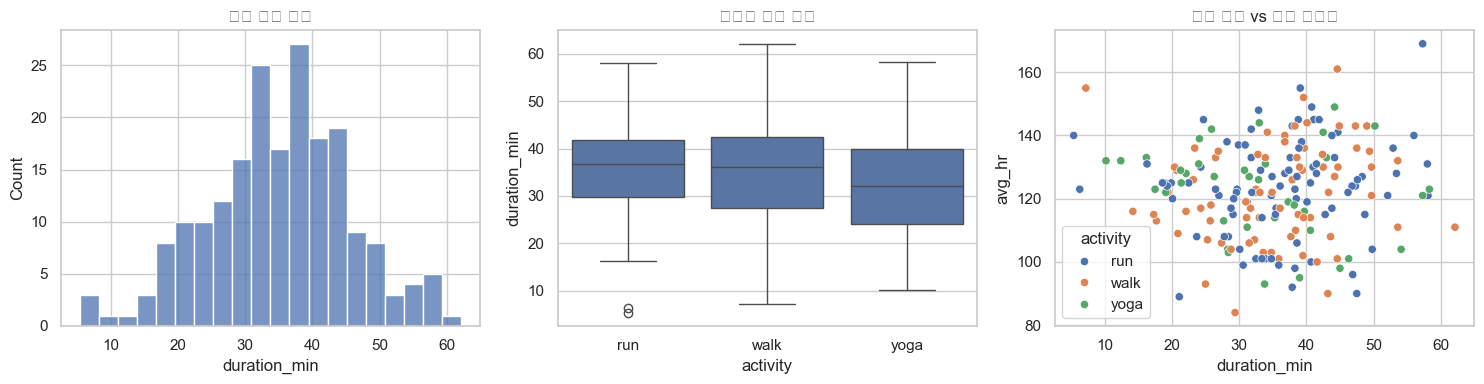

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 히스토그램
sns.histplot(df, x="duration_min", bins=20, ax=axes[0])
axes[0].set_title("운동 시간 분포")

# 박스플롯
sns.boxplot(df, x="activity", y="duration_min", ax=axes[1])
axes[1].set_title("활동별 운동 시간")

# 산점도
sns.scatterplot(df, x="duration_min", y="avg_hr", hue="activity", ax=axes[2])
axes[2].set_title("운동 시간 vs 평균 심박수")

plt.tight_layout(); plt.show()


## 4. 기록·재현 — 시드와 결정성

학습용 시뮬레이션은 매번 같은 결과가 나와야 본문과 같은 그림이 학습자 PC 에서도 보입니다. 이 저장소는 항상 `np.random.default_rng(seed=...)` 를 통해 *시드를 박은* 난수를 사용합니다.


In [8]:
rng_a = np.random.default_rng(seed=0)
rng_b = np.random.default_rng(seed=0)
print(rng_a.normal(size=3))
print(rng_b.normal(size=3))
print("두 줄이 같으면 시드가 의도대로 동작 중")


[ 0.12573022 -0.13210486  0.64042265]
[ 0.12573022 -0.13210486  0.64042265]
두 줄이 같으면 시드가 의도대로 동작 중


## 5. 작은 통계 — 평균·중앙값 한 번에

1 모듈에서 본격적으로 다룰 *기술통계* 의 맛보기입니다.


In [9]:
df["duration_min"].describe()


count    200.000000
mean      35.073500
std       10.703113
min        5.400000
25%       28.375000
50%       35.350000
75%       41.675000
max       62.100000
Name: duration_min, dtype: float64

In [10]:
print(f"평균:   {df['duration_min'].mean():.2f}")
print(f"중앙값: {df['duration_min'].median():.2f}")
print(f"표준편차: {df['duration_min'].std(ddof=1):.2f}")
print(f"IQR:    {df['duration_min'].quantile(0.75) - df['duration_min'].quantile(0.25):.2f}")


평균:   35.07
중앙값: 35.35
표준편차: 10.70
IQR:    13.30


## 정리

오늘 본 것은 다음 모듈부터 *끊임없이 반복* 됩니다. 외우지 않고도 다음 사실만 기억하세요.

1. NumPy 는 *벡터* 단위로 사고. for-loop 대신 배열 연산.
2. Pandas 는 *표* 단위로 사고. 행 선택 → 그룹 → 집계.
3. 시각화는 *분포 모양* 부터 본다. 히스토그램·박스플롯·산점도.
4. 시뮬레이션은 *시드를 박는다*.

다음 모듈로 넘어가세요 → [`../01-descriptive-stats/01-when-mean-lies.md`](../01-descriptive-stats/01-when-mean-lies.md)
